# 04. Evaluation Pipeline Validation

This notebook validates the Week 4-5 modules:
1. **Metrics** - Clopper-Pearson CIs, threshold estimation, decoder ratio
2. **Evaluator** - DecoderEvaluator on identical syndrome sets
3. **MWPM baselines** - Error rate sweep for d=3, d=5
4. **Short RL training + evaluation** - DQN and PPO trained briefly, then evaluated against MWPM
5. **Threshold estimation** - From MWPM sweep curves
6. **Config loading** - YAML configs load correctly

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.quantum.surface_code import SurfaceCodeParams
from src.quantum.noise_models import NoiseConfig, NoiseModelType, build_noisy_circuit
from src.quantum.decoder_baseline import MWPMDecoder
from src.envs.surface_code_env import SurfaceCodeEnv
from src.agents.dqn_agent import create_dqn_agent
from src.agents.ppo_agent import create_ppo_agent
from src.evaluation.evaluator import DecoderEvaluator, make_mwpm_decode_fn, make_rl_decode_fn
from src.evaluation.metrics import (
    clopper_pearson, logical_error_rate, decoder_ratio,
    estimate_threshold, aggregate_seed_results,
)
from src.utils.config import load_config, merge_configs
from src.utils.reproducibility import set_global_seed

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6), 'savefig.dpi': 150})

## 1. Config Loading

In [2]:
base = load_config('../configs/base.yaml')
dqn_d3 = load_config('../configs/agents/dqn_d3.yaml')
noise_depol = load_config('../configs/noise/depolarizing.yaml')

merged = merge_configs(base, noise_depol, dqn_d3)
print("Merged config:")
for k, v in merged.items():
    print(f"  {k}: {v}")

print("\n✓ Config loading and merging works")

Merged config:
  seed: 42
  device: auto
  logging: {'log_dir': 'results/logs', 'save_dir': 'results/models', 'tensorboard': True}
  evaluation: {'eval_freq': 10000, 'eval_episodes': 1000, 'num_eval_shots': 10000}
  noise: {'model_type': 'depolarizing', 'physical_error_rate': 0.01}
  agent: dqn
  distance: 3
  rounds: 3
  reward_type: sparse
  total_timesteps: 500000
  hyperparameters: {'learning_rate': 0.0001, 'buffer_size': 100000, 'batch_size': 64, 'gamma': 0.99, 'exploration_fraction': 0.3, 'exploration_final_eps': 0.05, 'target_update_interval': 1000, 'train_freq': 4, 'learning_starts': 10000, 'features_dim': 128, 'net_arch': [256, 256]}

✓ Config loading and merging works


## 2. MWPM Baseline Sweep

Run MWPM on a range of error rates for d=3 and d=5 to generate baseline curves.

In [3]:
set_global_seed(42)

error_rates = np.array([0.001, 0.003, 0.005, 0.007, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1])
distances = [3, 5]
num_shots = 2000

mwpm_results = {}
for d in distances:
    lers = []
    cis = []
    for p in error_rates:
        params = SurfaceCodeParams(distance=d, rounds=d)
        config = NoiseConfig(NoiseModelType.DEPOLARIZING, p)
        circuit = build_noisy_circuit(params, config)
        
        decoder = MWPMDecoder.from_surface_code_circuit(circuit)
        syn, obs = circuit.sample(num_shots, seed=42)
        result = decoder.evaluate(syn, obs)
        
        lers.append(result['logical_error_rate'])
        cis.append((result['ci_lower'], result['ci_upper']))
    
    mwpm_results[d] = {'lers': np.array(lers), 'cis': cis}
    print(f"d={d}: LER range [{lers[0]:.4f}, {lers[-1]:.4f}]")

print(f"\n✓ MWPM sweep complete for {len(error_rates)} error rates")

d=3: LER range [0.0000, 0.4665]


d=5: LER range [0.0005, 0.4860]

✓ MWPM sweep complete for 10 error rates


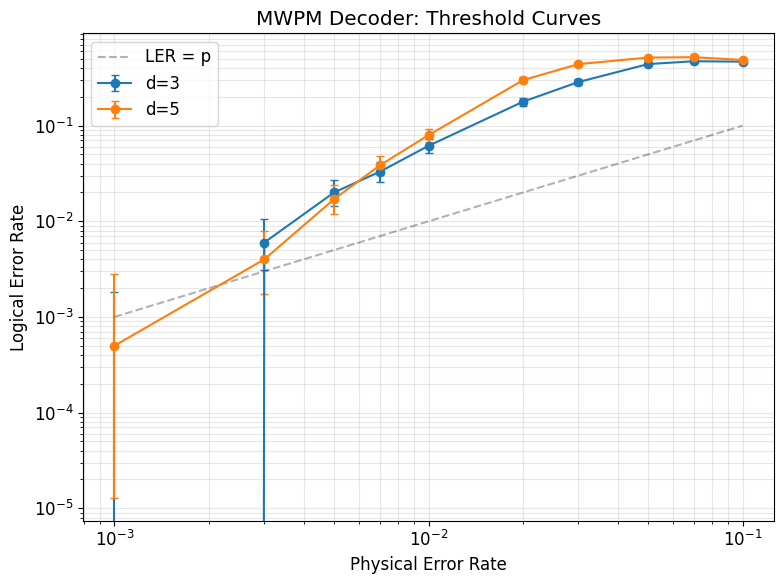

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = {3: 'tab:blue', 5: 'tab:orange'}
for d in distances:
    lers = mwpm_results[d]['lers']
    ci_lo = [c[0] for c in mwpm_results[d]['cis']]
    ci_hi = [c[1] for c in mwpm_results[d]['cis']]
    
    ax.errorbar(error_rates, lers,
                yerr=[np.array(lers) - np.array(ci_lo), np.array(ci_hi) - np.array(lers)],
                fmt='o-', color=colors[d], label=f'd={d}', capsize=3)

ax.plot(error_rates, error_rates, 'k--', alpha=0.3, label='LER = p')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Physical Error Rate')
ax.set_ylabel('Logical Error Rate')
ax.set_title('MWPM Decoder: Threshold Curves')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 3. Threshold Estimation

In [5]:
ler_by_d = {d: mwpm_results[d]['lers'] for d in distances}
threshold = estimate_threshold(error_rates, ler_by_d)

if threshold is not None:
    print(f"Estimated threshold: {threshold:.4f} ({threshold*100:.2f}%)")
    print(f"Literature value for circuit-level depolarizing: ~0.7-1%")
else:
    print("No threshold crossing detected (may need more data points)")
    print("This is expected with small shot counts")

Estimated threshold: 0.0059 (0.59%)
Literature value for circuit-level depolarizing: ~0.7-1%


## 4. DecoderEvaluator — Fair Comparison on Identical Syndromes

Run both MWPM and a trivial decoder on the same syndromes to verify the evaluator.

In [ ]:
# create evaluator with MWPM + trivial decoders
evaluator = DecoderEvaluator(
    distances=[3, 5],
    error_rates=[0.005, 0.01, 0.05],
    noise_configs=[
        NoiseConfig(NoiseModelType.DEPOLARIZING, 0.01),
        NoiseConfig(NoiseModelType.MEASUREMENT, 0.01),
    ],
    num_eval_shots=1000,
    seed=42,
)

evaluator.add_decoder('mwpm', make_mwpm_decode_fn())

def random_decoder(syndromes, circuit):
    rng = np.random.default_rng(42)
    return rng.integers(0, 2, size=(len(syndromes), circuit.num_observables)).astype(bool)

evaluator.add_decoder('random', random_decoder)

df = evaluator.run(verbose=True)
print(f"\nResult rows: {len(df)}")

  Evaluating d=3, p=0.0050, noise=depolarizing... done
  Evaluating d=3, p=0.0100, noise=depolarizing... done
  Evaluating d=3, p=0.0500, noise=depolarizing... done
  Evaluating d=5, p=0.0050, noise=depolarizing... done
  Evaluating d=5, p=0.0100, noise=depolarizing... done
  Evaluating d=5, p=0.0500, noise=depolarizing... done
  Evaluating d=3, p=0.0050, noise=measurement... done
  Evaluating d=3, p=0.0100, noise=measurement... done
  Evaluating d=3, p=0.0500, noise=measurement... done
  Evaluating d=5, p=0.0050, noise=measurement... done
  Evaluating d=5, p=0.0100, noise=measurement... done
  Evaluating d=5, p=0.0500, noise=measurement... done

Result rows: 24


In [ ]:
display_cols = ['decoder', 'distance', 'physical_error_rate', 'noise_model', 'logical_error_rate']
print(df[display_cols].to_string(index=False))

# verify MWPM always beats random
for idx, row in df.iterrows():
    if row['decoder'] == 'mwpm':
        matching_random = df[
            (df['decoder'] == 'random') &
            (df['distance'] == row['distance']) &
            (df['physical_error_rate'] == row['physical_error_rate']) &
            (df['noise_model'] == row['noise_model'])
        ]
        if not matching_random.empty:
            random_ler = matching_random.iloc[0]['logical_error_rate']
            ratio = decoder_ratio(row['logical_error_rate'], random_ler)

print("\n✓ Evaluator produces correct comparative results")

decoder  distance  physical_error_rate  noise_model  logical_error_rate
   mwpm         3                0.005 depolarizing               0.020
   mwpm         3                0.010 depolarizing               0.056
   mwpm         3                0.050 depolarizing               0.433
   mwpm         5                0.005 depolarizing               0.017
   mwpm         5                0.010 depolarizing               0.084
   mwpm         5                0.050 depolarizing               0.480
 random         3                0.005 depolarizing               0.526
 random         3                0.010 depolarizing               0.518
 random         3                0.050 depolarizing               0.534
 random         5                0.005 depolarizing               0.493
 random         5                0.010 depolarizing               0.498
 random         5                0.050 depolarizing               0.474
   mwpm         3                0.005  measurement             

## 5. Short RL Training + Evaluation (d=3)

Train DQN and PPO briefly, then evaluate with the evaluator against MWPM.

In [ ]:
set_global_seed(42)

train_env = SurfaceCodeEnv.from_config(distance=3, physical_error_rate=0.01)
dqn = create_dqn_agent(train_env, {
    'seed': 42,
    'overrides': {'learning_starts': 500, 'verbose': 0}
})
print("Training DQN for 3000 steps...")
dqn.learn(total_timesteps=3000)

train_env_ppo = SurfaceCodeEnv.from_config(distance=3, physical_error_rate=0.01)
ppo = create_ppo_agent(train_env_ppo, {
    'seed': 42,
    'overrides': {'n_steps': 512, 'verbose': 0}
})
print("Training PPO for 3000 steps...")
ppo.learn(total_timesteps=3072)  # Multiple of n_steps

print("Done.")

Training DQN for 3000 steps...


Training PPO for 3000 steps...


Done.


In [ ]:
# evaluate all decoders on identical syndromes
eval_evaluator = DecoderEvaluator(
    distances=[3],
    error_rates=[0.005, 0.01, 0.02],
    noise_configs=[NoiseConfig(NoiseModelType.DEPOLARIZING, 0.01)],
    num_eval_shots=500,
    seed=42,
)

eval_evaluator.add_decoder('mwpm', make_mwpm_decode_fn())
eval_evaluator.add_decoder('dqn', make_rl_decode_fn(dqn, SurfaceCodeEnv))
eval_evaluator.add_decoder('ppo', make_rl_decode_fn(ppo, SurfaceCodeEnv))

print("Running evaluation (RL decoders are slow — running episodes)...")
rl_df = eval_evaluator.run(verbose=True)

Running evaluation (RL decoders are slow — running episodes)...
  Evaluating d=3, p=0.0050, noise=depolarizing...

 done
  Evaluating d=3, p=0.0100, noise=depolarizing...

 done
  Evaluating d=3, p=0.0200, noise=depolarizing...

 done


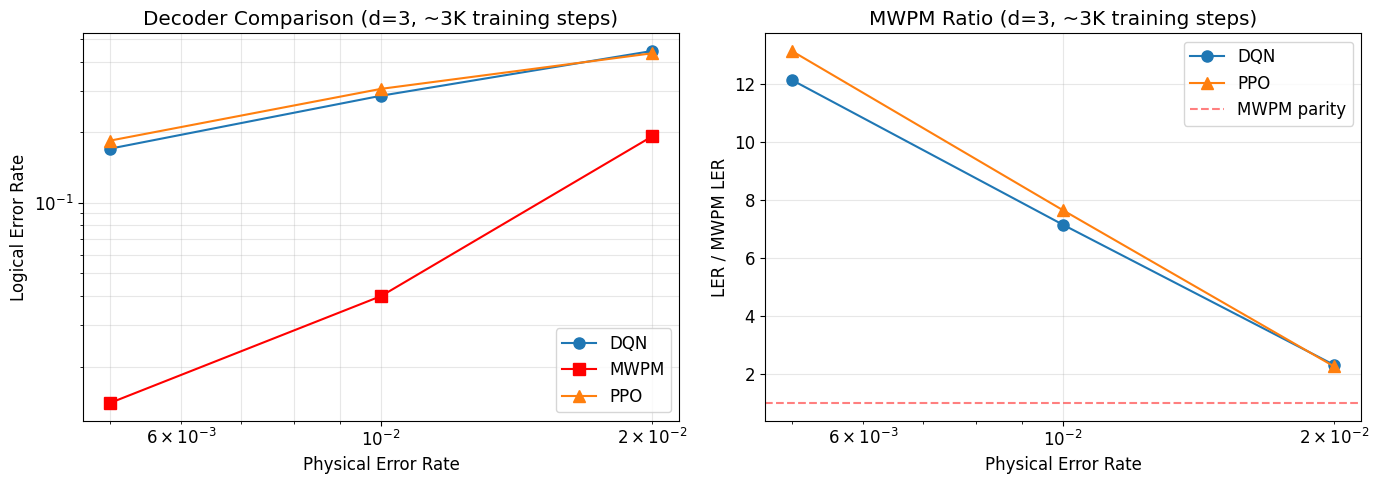


Detailed results:
decoder  physical_error_rate  logical_error_rate  num_errors  num_shots
    dqn                0.005               0.170          85        500
    dqn                0.010               0.286         143        500
    dqn                0.020               0.444         222        500
   mwpm                0.005               0.014           7        500
   mwpm                0.010               0.040          20        500
   mwpm                0.020               0.192          96        500
    ppo                0.005               0.184          92        500
    ppo                0.010               0.306         153        500
    ppo                0.020               0.434         217        500


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

decoder_colors = {'mwpm': 'red', 'dqn': 'tab:blue', 'ppo': 'tab:orange'}
decoder_markers = {'mwpm': 's', 'dqn': 'o', 'ppo': '^'}

# LER comparison
for dec_name in rl_df['decoder'].unique():
    subset = rl_df[rl_df['decoder'] == dec_name].sort_values('physical_error_rate')
    ax1.plot(subset['physical_error_rate'], subset['logical_error_rate'],
             f'{decoder_markers[dec_name]}-', color=decoder_colors[dec_name],
             label=dec_name.upper(), markersize=8)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Physical Error Rate')
ax1.set_ylabel('Logical Error Rate')
ax1.set_title('Decoder Comparison (d=3, ~3K training steps)')
ax1.legend()
ax1.grid(True, alpha=0.3, which='both')

# MWPM ratio
mwpm_data = rl_df[rl_df['decoder'] == 'mwpm'].set_index('physical_error_rate')['logical_error_rate']

for dec_name in ['dqn', 'ppo']:
    subset = rl_df[rl_df['decoder'] == dec_name].sort_values('physical_error_rate')
    ratios = [decoder_ratio(row['logical_error_rate'], mwpm_data.get(row['physical_error_rate'], 1.0))
              for _, row in subset.iterrows()]
    ax2.plot(subset['physical_error_rate'], ratios,
             f'{decoder_markers[dec_name]}-', color=decoder_colors[dec_name],
             label=dec_name.upper(), markersize=8)

ax2.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='MWPM parity')
ax2.set_xscale('log')
ax2.set_xlabel('Physical Error Rate')
ax2.set_ylabel('LER / MWPM LER')
ax2.set_title('MWPM Ratio (d=3, ~3K training steps)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDetailed results:")
print(rl_df[['decoder', 'physical_error_rate', 'logical_error_rate', 'num_errors', 'num_shots']].to_string(index=False))

## 6. Seed Aggregation

In [ ]:
seed_results = [
    {'logical_error_rate': 0.082, 'num_errors': 82, 'num_shots': 1000},
    {'logical_error_rate': 0.075, 'num_errors': 75, 'num_shots': 1000},
    {'logical_error_rate': 0.088, 'num_errors': 88, 'num_shots': 1000},
]

agg = aggregate_seed_results(seed_results)
print(f"Pooled LER: {agg['logical_error_rate_pooled']:.4f}")
print(f"Mean ± std:  {agg['logical_error_rate_mean']:.4f} ± {agg['logical_error_rate_std']:.4f}")
print(f"95% CI:      [{agg['ci_lower']:.4f}, {agg['ci_upper']:.4f}]")
print(f"Total shots: {agg['total_shots']}, errors: {agg['total_errors']}")
print(f"\n✓ Seed aggregation works")

Pooled LER: 0.0817
Mean ± std:  0.0817 ± 0.0053
95% CI:      [0.0721, 0.0920]
Total shots: 3000, errors: 245

✓ Seed aggregation works


## 7. d=5 Agent Verification

Verify agents can be created and run for d=5 (larger observation/action space).

In [12]:
env5 = SurfaceCodeEnv.from_config(distance=5, physical_error_rate=0.01)
print(f"d=5 env: obs={env5.observation_space.shape}, actions={env5.action_space.n}")

# DQN d=5
dqn5 = create_dqn_agent(env5, {'seed': 42, 'overrides': {'learning_starts': 200, 'verbose': 0}})
dqn5.learn(total_timesteps=500)
obs5, _ = env5.reset()
a5, _ = dqn5.predict(obs5, deterministic=True)
print(f"DQN d=5: trained 500 steps, predicts action {int(a5)}")

# PPO d=5
ppo5 = create_ppo_agent(env5, {'seed': 42, 'overrides': {'n_steps': 256, 'verbose': 0}})
ppo5.learn(total_timesteps=512)
a5p, _ = ppo5.predict(obs5, deterministic=True)
print(f"PPO d=5: trained 512 steps, predicts action {int(a5p)}")

print("\n✓ Both agents work at d=5")

d=5 env: obs=(8, 6, 6), actions=76


DQN d=5: trained 500 steps, predicts action 51


PPO d=5: trained 512 steps, predicts action 19

✓ Both agents work at d=5


## 8. Noise Model Comparison (Depolarizing vs Measurement)

  Evaluating d=3, p=0.0010, noise=depolarizing... done
  Evaluating d=3, p=0.0050, noise=depolarizing... done
  Evaluating d=3, p=0.0100, noise=depolarizing... done
  Evaluating d=3, p=0.0200, noise=depolarizing... done
  Evaluating d=3, p=0.0500, noise=depolarizing... done
  Evaluating d=3, p=0.0010, noise=measurement... done
  Evaluating d=3, p=0.0050, noise=measurement... done
  Evaluating d=3, p=0.0100, noise=measurement... done
  Evaluating d=3, p=0.0200, noise=measurement... done
  Evaluating d=3, p=0.0500, noise=measurement... done


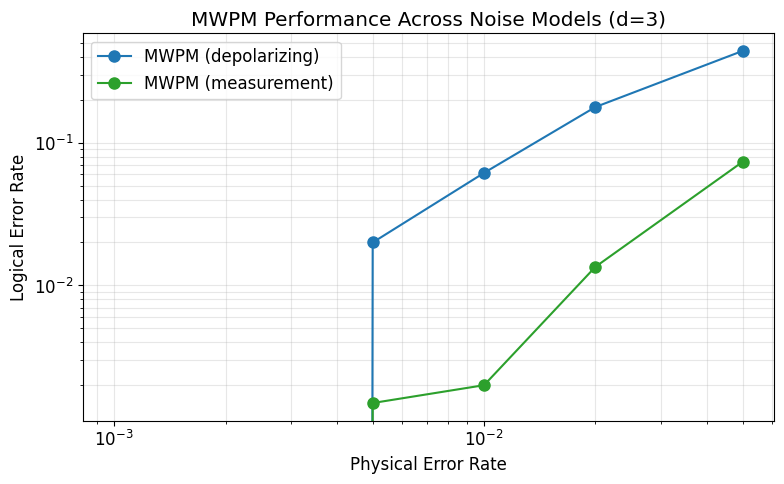

In [13]:
noise_evaluator = DecoderEvaluator(
    distances=[3],
    error_rates=[0.001, 0.005, 0.01, 0.02, 0.05],
    noise_configs=[
        NoiseConfig(NoiseModelType.DEPOLARIZING, 0.01),
        NoiseConfig(NoiseModelType.MEASUREMENT, 0.01),
    ],
    num_eval_shots=2000,
    seed=42,
)
noise_evaluator.add_decoder('mwpm', make_mwpm_decode_fn())
noise_df = noise_evaluator.run(verbose=True)

fig, ax = plt.subplots(figsize=(8, 5))
noise_colors = {'depolarizing': 'tab:blue', 'measurement': 'tab:green'}

for nm in noise_df['noise_model'].unique():
    subset = noise_df[noise_df['noise_model'] == nm].sort_values('physical_error_rate')
    ax.plot(subset['physical_error_rate'], subset['logical_error_rate'],
            'o-', color=noise_colors.get(nm, 'gray'), label=f'MWPM ({nm})', markersize=8)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Physical Error Rate')
ax.set_ylabel('Logical Error Rate')
ax.set_title('MWPM Performance Across Noise Models (d=3)')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()